In [1]:
import json
import os
import sys
from pathlib import Path
from datetime import datetime

import numpy as np
import wandb
from dotenv import load_dotenv

sys.path.append(os.path.abspath(".."))

import src.utils.hill_climbing as hc
from src.utils.telegram import send_message

In [3]:
# Load data
load_dotenv(dotenv_path="../../.env")
data_id: int = 34
level: str = "l2"

In [ ]:
# === WANDB ===
wandb_project = os.environ.get("COMPETITION_NAME")
wandb.login(key=os.environ.get("WANDB_API_KEY"))

run = wandb.init(
    project=wandb_project,
    group=f"hc-{data_id}",
    name=data_id,
    job_type="cv_training",
    tags=[hc, level],
    config={
        "data_id": data_id
    },
    dir="../../artifacts"
)

0 We begin with best single model AUC 0.97647 from 3
New best score: 0.97664
adding: 0
with weight: 0.350

New best score: 0.97667
adding: 5
with weight: 0.240

=> We reached tolerance 1e-05
   model  weight
0      3   0.494
1      0   0.266
2      5   0.240


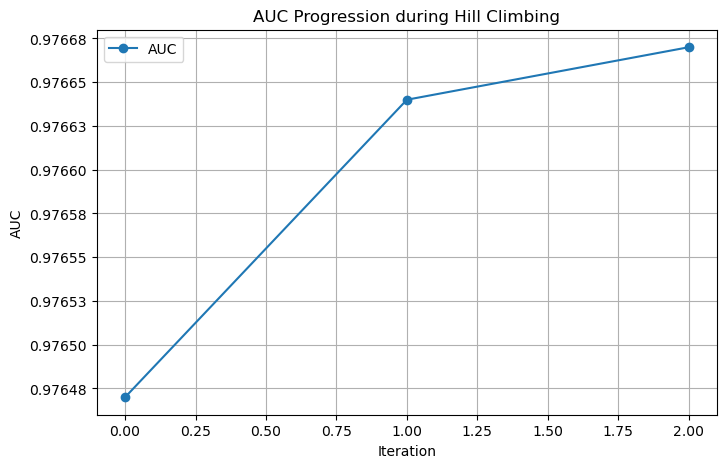

In [4]:
# Hill Climbing
result = hc.hill_climbing_auc(2)

In [6]:
# save oof pred and test pred
run_id = Path(f"hc-{data_id}")
run_dir = "../../runs" / run_id
run_dir.mkdir(parents=True, exist_ok=True)

feature_dir = Path(f"../../artifacts/features/{data_id}")

manifest = {
    "run_id": run_id,
    "wandb_id": run.id,
    "wandb_url": run.url,
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model_name": "hc",
    "data_id": data_id,
    "feature_dir": str(feature_dir.resolve()),
    "run_dir": str(run_dir.resolve()),
    "cv_score": result.oof_score,
    "submission": {
        "competition": None,
        "ref": None,
        "file": None,
        "public_score": None,
        "private_score": None,
        "submitted_at": None
    }
}

with open(run_dir / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=4)

print("manifest saved", run_dir / "manifest.json")

# oof and test pred
np.save(run_dir / "oof.npy", result.oof)
np.save(run_dir / "test.npy", result.test_pred)

print(f"oof and test preds saved successfully in:\n{run_dir}")
send_message(
    f"✅ Finished CV for {run_id}!"
    f"\nScore: {round(result.oof_score, 5)}"
)

Saved submission file successfully!
